In [4]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [5]:
# Load the dataset
df = pd.read_csv('Amazon Sale Report.csv')

# Preview the data
print('Shape:', df.shape)
print()
print(df.head())

C:\Users\USER\AppData\Local\Temp\ipykernel_8396\4282319206.py:2: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Amazon Sale Report.csv')


Shape: (128975, 24)

   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant      Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category  ... currency  Amount    ship-city   ship-state  \
0            Se

In [6]:
# Data Cleaning
# Keep only relevant columns
df = df[['Order ID', 'Date', 'Status', 'Fulfilment', 'Category', 
         'Size', 'Qty', 'Amount', 'ship-city', 'ship-state', 'B2B']]

# Rename columns for easier use
df.columns = ['OrderID', 'Date', 'Status', 'Fulfilment', 'Category', 
              'Size', 'Quantity', 'Amount', 'City', 'State', 'B2B']

# Drop rows where Amount is missing
df = df.dropna(subset=['Amount'])

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y')

# Extract Month for trend analysis
df['Month'] = df['Date'].dt.strftime('%b')
df['MonthNum'] = df['Date'].dt.month

print('Cleaned data shape:', df.shape)
print()
print(df.head())

Cleaned data shape: (121180, 13)

               OrderID       Date                        Status Fulfilment  \
0  405-8078784-5731545 2022-04-30                     Cancelled   Merchant   
1  171-9198151-1101146 2022-04-30  Shipped - Delivered to Buyer   Merchant   
2  404-0687676-7273146 2022-04-30                       Shipped     Amazon   
3  403-9615377-8133951 2022-04-30                     Cancelled   Merchant   
4  407-1069790-7240320 2022-04-30                       Shipped     Amazon   

        Category Size  Quantity  Amount         City        State    B2B  \
0            Set    S         0  647.62       MUMBAI  MAHARASHTRA  False   
1          kurta  3XL         1  406.00    BENGALURU    KARNATAKA  False   
2          kurta   XL         1  329.00  NAVI MUMBAI  MAHARASHTRA   True   
3  Western Dress    L         0  753.33   PUDUCHERRY   PUDUCHERRY  False   
4            Top  3XL         1  574.00      CHENNAI   TAMIL NADU  False   

  Month  MonthNum  
0   Apr         4  


In [7]:
# Analysis 1: Overall Sales Overview
total_orders = df['OrderID'].nunique()
total_revenue = df['Amount'].sum()
avg_order_value = df['Amount'].mean()
total_quantity = df['Quantity'].sum()

print('===== SALES OVERVIEW =====')
print(f'Total Orders:      {total_orders:,}')
print(f'Total Revenue:     ₹{total_revenue:,.2f}')
print(f'Avg Order Value:   ₹{avg_order_value:,.2f}')
print(f'Total Units Sold:  {total_quantity:,}')

===== SALES OVERVIEW =====
Total Orders:      113,030
Total Revenue:     ₹78,592,678.30
Avg Order Value:   ₹648.56
Total Units Sold:  116,482


===== REVENUE BY CATEGORY =====
        Category  TotalRevenue
0            Set   39204124.03
1          kurta   21299546.70
2  Western Dress   11216072.69
3            Top    5347792.30
4   Ethnic Dress     791217.66
5         Blouse     458408.18
6         Bottom     150667.98
7          Saree     123933.76
8        Dupatta        915.00


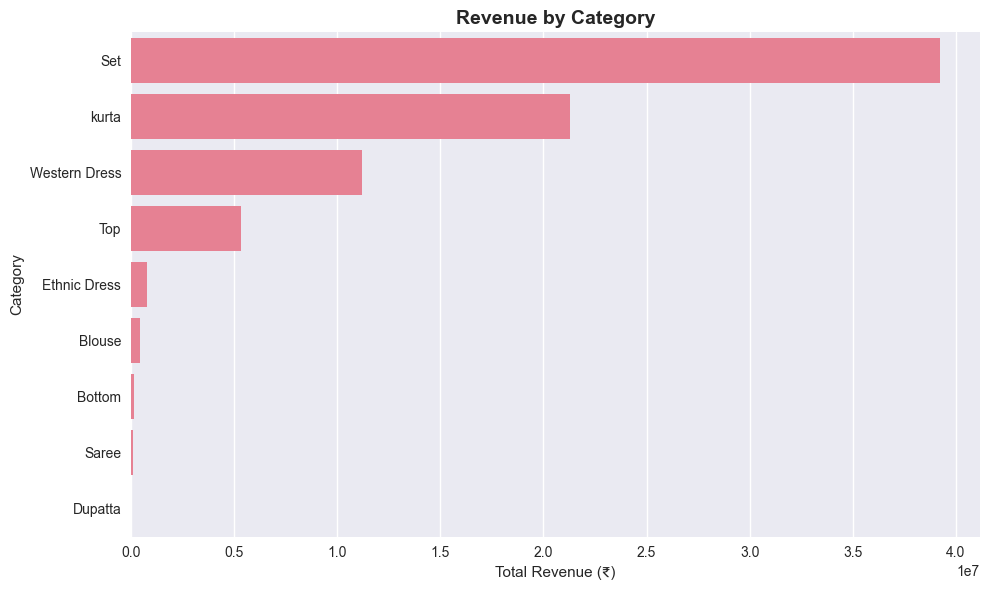

In [8]:
# Analysis 2: Revenue by Category
category_revenue = df.groupby('Category')['Amount'].sum().sort_values(ascending=False).reset_index()
category_revenue.columns = ['Category', 'TotalRevenue']
category_revenue['TotalRevenue'] = category_revenue['TotalRevenue'].round(2)

print('===== REVENUE BY CATEGORY =====')
print(category_revenue)

# Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=category_revenue, x='TotalRevenue', y='Category')
plt.title('Revenue by Category', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (₹)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

===== MONTHLY REVENUE TREND =====
  Month       Amount
0   Mar    101683.85
1   Apr  28838708.32
2   May  26226476.75
3   Jun  23425809.38


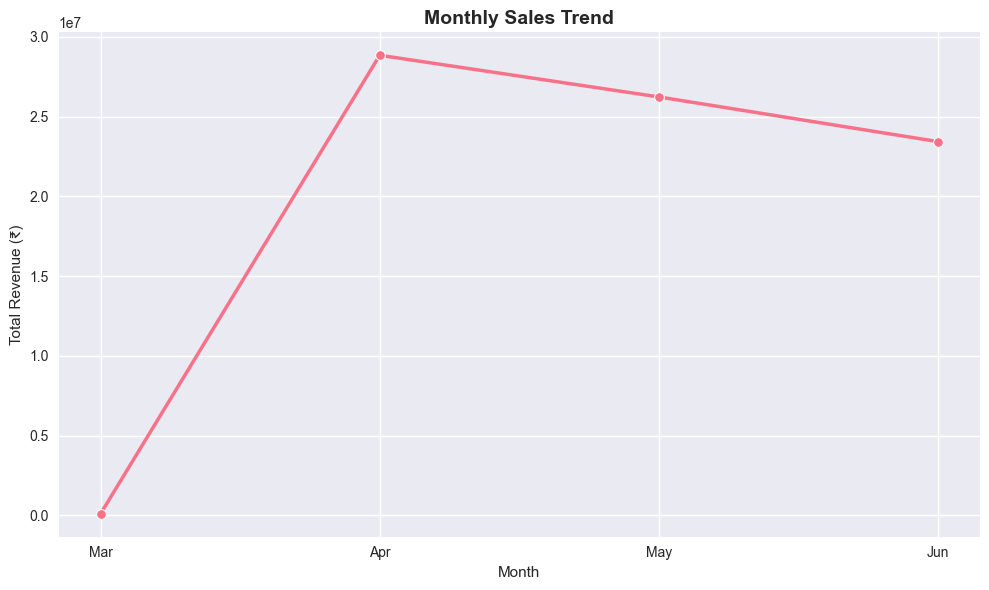

In [9]:
# Analysis 3: Monthly Sales Trend
monthly_revenue = df.groupby(['MonthNum', 'Month'])['Amount'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('MonthNum')
monthly_revenue['Amount'] = monthly_revenue['Amount'].round(2)

print('===== MONTHLY REVENUE TREND =====')
print(monthly_revenue[['Month', 'Amount']])

# Chart
plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_revenue, x='Month', y='Amount', marker='o', linewidth=2.5)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (₹)')
plt.tight_layout()
plt.show()

===== ORDER STATUS BREAKDOWN =====
                           Status  OrderCount  Percentage
0                         Shipped       77596       64.03
1    Shipped - Delivered to Buyer       28761       23.73
2                       Cancelled       10766        8.88
3    Shipped - Returned to Seller        1950        1.61
4             Shipped - Picked Up         973        0.80
5                         Pending         656        0.54
6   Pending - Waiting for Pick Up         281        0.23
7   Shipped - Returning to Seller         145        0.12
8      Shipped - Out for Delivery          35        0.03
9     Shipped - Rejected by Buyer          11        0.01
10      Shipped - Lost in Transit           5        0.00
11              Shipped - Damaged           1        0.00


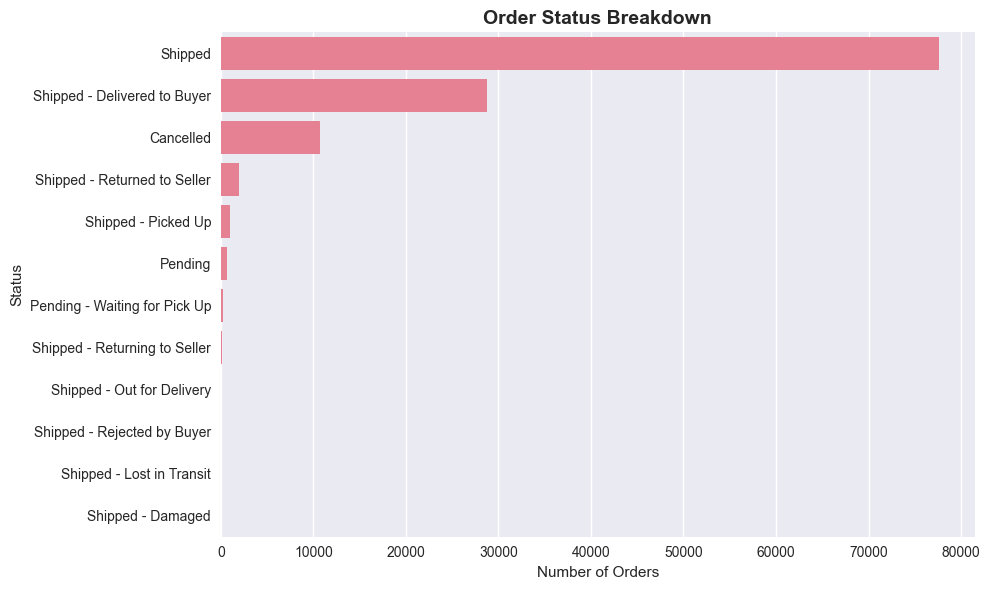

In [10]:
# Analysis 4: Order Status Breakdown
status_counts = df.groupby('Status')['OrderID'].count().sort_values(ascending=False).reset_index()
status_counts.columns = ['Status', 'OrderCount']
status_counts['Percentage'] = (status_counts['OrderCount'] / status_counts['OrderCount'].sum() * 100).round(2)

print('===== ORDER STATUS BREAKDOWN =====')
print(status_counts)

# Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=status_counts, x='OrderCount', y='Status')
plt.title('Order Status Breakdown', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders')
plt.ylabel('Status')
plt.tight_layout()
plt.show()

===== TOP 10 STATES BY REVENUE =====
            State  TotalRevenue
0     MAHARASHTRA   13335534.14
1       KARNATAKA   10481114.37
2       TELANGANA    6916615.65
3   UTTAR PRADESH    6816642.08
4      TAMIL NADU    6515650.11
5           DELHI    4235215.97
6          KERALA    3830227.58
7     WEST BENGAL    3507880.44
8  ANDHRA PRADESH    3219831.72
9         HARYANA    2882092.99


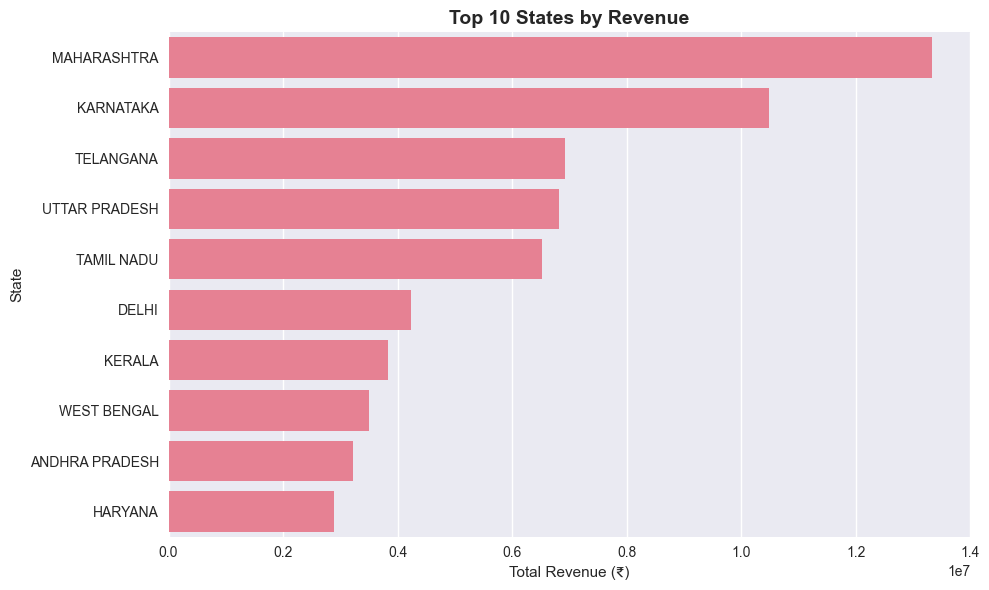

In [11]:
# Analysis 5: Top 10 States by Revenue
state_revenue = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10).reset_index()
state_revenue.columns = ['State', 'TotalRevenue']
state_revenue['TotalRevenue'] = state_revenue['TotalRevenue'].round(2)

print('===== TOP 10 STATES BY REVENUE =====')
print(state_revenue)

# Chart
plt.figure(figsize=(10, 6))
sns.barplot(data=state_revenue, x='TotalRevenue', y='State')
plt.title('Top 10 States by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (₹)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

===== B2B vs B2C COMPARISON =====
   B2B  TotalRevenue  OrderCount  AvgOrderValue
0  B2C   78001457.51      120337         648.19
1  B2B     591220.79         843         701.33


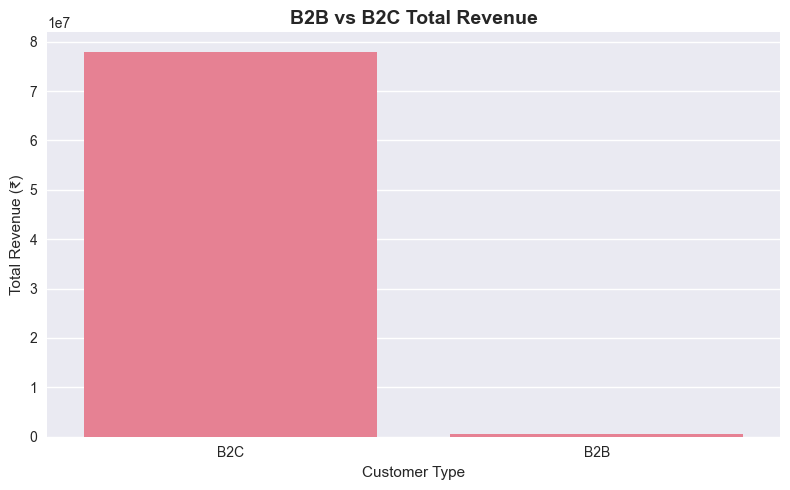

In [12]:
# Analysis 6: B2B vs B2C Revenue Comparison
b2b_revenue = df.groupby('B2B')['Amount'].agg(['sum', 'count', 'mean']).reset_index()
b2b_revenue.columns = ['B2B', 'TotalRevenue', 'OrderCount', 'AvgOrderValue']
b2b_revenue['B2B'] = b2b_revenue['B2B'].map({True: 'B2B', False: 'B2C'})
b2b_revenue['TotalRevenue'] = b2b_revenue['TotalRevenue'].round(2)
b2b_revenue['AvgOrderValue'] = b2b_revenue['AvgOrderValue'].round(2)

print('===== B2B vs B2C COMPARISON =====')
print(b2b_revenue)

# Chart
plt.figure(figsize=(8, 5))
sns.barplot(data=b2b_revenue, x='B2B', y='TotalRevenue')
plt.title('B2B vs B2C Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Customer Type')
plt.ylabel('Total Revenue (₹)')
plt.tight_layout()
plt.show()